In [1]:
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score,confusion_matrix 

import seaborn as sns
import pandas as pd 
import numpy as np 

In [3]:
data = sns.load_dataset('iris')

In [4]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
encoder = LabelEncoder()

data['species'] = encoder.fit_transform(data['species'])

In [7]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df = data[['sepal_length','petal_length','species']] 

df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [9]:
df.shape

(150, 3)

In [15]:
df.iloc[:,-1:]

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [16]:
X_train,X_test,y_train,y_test = train_test_split(
    df.iloc[:,:2],df.iloc[:,-1:], test_size= 0.2, random_state= 42)

In [17]:
lor = LogisticRegression( multi_class= 'multinomial')

lor.fit(X_train,y_train)

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [18]:
y_pred = lor.predict(X_test)

In [19]:
accuracy_score(y_test,y_pred)

1.0

In [21]:
print(confusion_matrix(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [24]:
test = np.array([[3.7,3]])
prediction= lor.predict_proba(test)*100
prediction

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[61.0001284 , 38.71034818,  0.28952341]])

In [26]:
np.sum(prediction)

100.00000000000001

In [27]:
lor.predict(test) # it predict the class, here it would be 0(setosa)

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [38]:
type(X_train)

pandas.core.frame.DataFrame

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

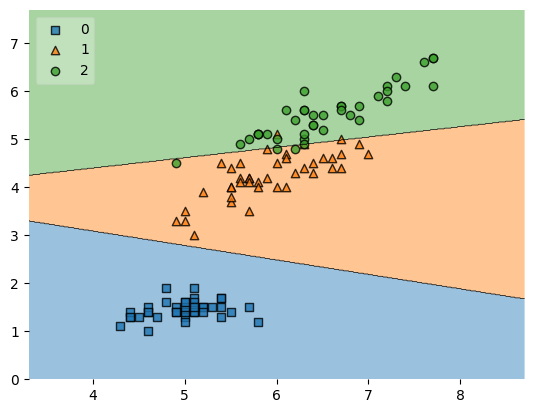

In [39]:
from mlxtend.plotting import plot_decision_regions 

plot_decision_regions(X_train.values,
                      y_train.values.ravel(),
                      clf=lor,
                      legend=2)


# DONE